<a href="https://colab.research.google.com/github/supiarianti/Halaman-Profil-Diri/blob/main/Tugas%20Hands_on_Tuning_Neural_Network_Supi_Arianti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Challenge Hands on Tuning Neural Network

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# download dan muat dataset fashion MNIST
fashion_mnist = keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# normalisasi pixel gambar (0-255 jadi 0-1)
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# bagi data training
x_val, x_train = x_train_full[:5000], x_train_full[5000:]
y_val, y_train = y_train_full[:5000], y_train_full[5000:]

print("Data train:", x_train.shape)
print("Data val:", x_val.shape)
print("Data test:", x_test.shape)

Data train: (55000, 28, 28)
Data val: (5000, 28, 28)
Data test: (10000, 28, 28)


In [8]:
# 1. arsitektur sederhana + SGD)
model_biasa = keras.Sequential([
    layers.Flatten(input_shape=[28, 28]),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# model baseline
model_biasa.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=["accuracy"]
)

# model baseline
print("--- Training Model Baseline ---")
history_biasa = model_biasa.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

# hasil di data test
loss_biasa, acc_biasa = model_biasa.evaluate(x_test, y_test)
print(f"Akurasi Baseline: {acc_biasa * 100:.2f}%")

--- Training Model Baseline ---
Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7586 - loss: 0.7558 - val_accuracy: 0.8194 - val_loss: 0.5524
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8214 - loss: 0.5218 - val_accuracy: 0.8336 - val_loss: 0.4847
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8345 - loss: 0.4759 - val_accuracy: 0.8428 - val_loss: 0.4543
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8431 - loss: 0.4505 - val_accuracy: 0.8500 - val_loss: 0.4393
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8488 - loss: 0.4318 - val_accuracy: 0.8510 - val_loss: 0.4269
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8529 - loss: 0.4172 - val_accuracy: 0.8534 - val_loss: 0.4157
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8581 - loss: 0.4062 - val_accuracy: 0.8636 - val_loss: 0.4018
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - ac

In [9]:
# 2. hasil Tuning & Regularisasi
model_tuning = keras.Sequential([
    layers.Flatten(input_shape=[28, 28]),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.2),  # Biar ga gampang overfitting
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

# gunakan optimizer adam dengan learning rate 0.001
model_tuning.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# callback Early Stopping
stop_pagi = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# model hasil tuning
print("\n--- Training Model Hasil Tuning ---")
history_tuning = model_tuning.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[stop_pagi]
)

# Cek hasil di data test
loss_tuning, acc_tuning = model_tuning.evaluate(x_test, y_test)
print(f"Akurasi Setelah Tuning: {acc_tuning * 100:.2f}%")


--- Training Model Hasil Tuning ---
Epoch 1/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8015 - loss: 0.5564 - val_accuracy: 0.8664 - val_loss: 0.3821
Epoch 2/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8497 - loss: 0.4118 - val_accuracy: 0.8666 - val_loss: 0.3571
Epoch 3/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8646 - loss: 0.3721 - val_accuracy: 0.8720 - val_loss: 0.3500
Epoch 4/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8722 - loss: 0.3489 - val_accuracy: 0.8768 - val_loss: 0.3319
Epoch 5/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8762 - loss: 0.3322 - val_accuracy: 0.8886 - val_loss: 0.3098
Epoch 6/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8834 - loss: 0.3179 - val_accuracy: 0.8864 - val_loss: 0.3080
Epoch 7/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8836 - loss: 0.3097 - val_accuracy: 0.8920 - val_loss: 0.3037
Epoch 8/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8

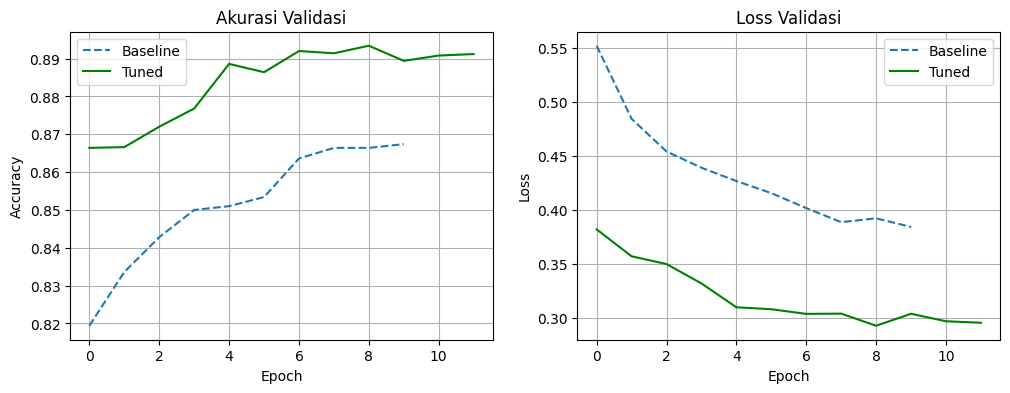

===== HASIL EXPERIMEN =====
Akurasi Baseline : 85.22%
Akurasi Tuning   : 88.34%
Selisih Peningkatan: +3.12%


In [10]:
# perbandingan akurasi dan loss
plt.figure(figsize=(12, 4))

# akurasi validasi
plt.subplot(1, 2, 1)
plt.plot(history_biasa.history['val_accuracy'], label='Baseline', linestyle='--')
plt.plot(history_tuning.history['val_accuracy'], label='Tuned', color='green')
plt.title('Akurasi Validasi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# loss validasi
plt.subplot(1, 2, 2)
plt.plot(history_biasa.history['val_loss'], label='Baseline', linestyle='--')
plt.plot(history_tuning.history['val_loss'], label='Tuned', color='green')
plt.title('Loss Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# lingkasan singkat
print("===== HASIL EXPERIMEN =====")
print(f"Akurasi Baseline : {acc_biasa * 100:.2f}%")
print(f"Akurasi Tuning   : {acc_tuning * 100:.2f}%")
print(f"Selisih Peningkatan: {(acc_tuning - acc_biasa) * 100:+.2f}%")